In [1]:
import sys
import pandas as pd
import numpy as np
import scipy
import sklearn

print("✅ CODEZILLA ML environment is working!")
print("Python:", sys.version)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("Scikit-learn:", sklearn.__version__)

✅ CODEZILLA ML environment is working!
Python: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
Pandas: 2.2.2
NumPy: 1.26.4
SciPy: 1.13.1
Scikit-learn: 1.5.1


In [1]:
import pandas as pd
from pathlib import Path

# Path to our downloaded dataset
file_path = Path("../data/raw/Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv")

# Load only the first 10,000 rows for initial inspection
df_sample = pd.read_csv(file_path, nrows=10_000)

print("✅ Dataset loaded successfully!")
print("Rows:", df_sample.shape[0])
print("Columns:", df_sample.shape[1])

✅ Dataset loaded successfully!
Rows: 10000
Columns: 80


In [2]:
df_sample.head()

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,6,21/02/2018 08:33:25,37953,5,3,135,127,135,0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,500,17,21/02/2018 08:33:06,117573474,3,0,1500,0,500,500,...,8,0.0,0.0,0,0,58800000.0,23800000.0,75600000,42000000,Benign
2,500,17,21/02/2018 08:33:06,117573474,3,0,1500,0,500,500,...,8,0.0,0.0,0,0,58800000.0,23800000.0,75600000,42000000,Benign
3,500,17,21/02/2018 08:33:11,99743998,5,0,2500,0,500,500,...,8,4000290.0,0.0,4000290,4000290,31900000.0,37900000.0,75600000,7200397,Benign
4,500,17,21/02/2018 08:33:11,99743999,5,0,2500,0,500,500,...,8,4000286.0,0.0,4000286,4000286,31900000.0,37900000.0,75600000,7200399,Benign


In [3]:
df_sample.columns.tolist()

['Dst Port',
 'Protocol',
 'Timestamp',
 'Flow Duration',
 'Tot Fwd Pkts',
 'Tot Bwd Pkts',
 'TotLen Fwd Pkts',
 'TotLen Bwd Pkts',
 'Fwd Pkt Len Max',
 'Fwd Pkt Len Min',
 'Fwd Pkt Len Mean',
 'Fwd Pkt Len Std',
 'Bwd Pkt Len Max',
 'Bwd Pkt Len Min',
 'Bwd Pkt Len Mean',
 'Bwd Pkt Len Std',
 'Flow Byts/s',
 'Flow Pkts/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Tot',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Tot',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Len',
 'Bwd Header Len',
 'Fwd Pkts/s',
 'Bwd Pkts/s',
 'Pkt Len Min',
 'Pkt Len Max',
 'Pkt Len Mean',
 'Pkt Len Std',
 'Pkt Len Var',
 'FIN Flag Cnt',
 'SYN Flag Cnt',
 'RST Flag Cnt',
 'PSH Flag Cnt',
 'ACK Flag Cnt',
 'URG Flag Cnt',
 'CWE Flag Count',
 'ECE Flag Cnt',
 'Down/Up Ratio',
 'Pkt Size Avg',
 'Fwd Seg Size Avg',
 'Bwd Seg Size Avg',
 'Fwd B

In [4]:
print(df_sample.columns.tolist())

['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd By

In [5]:
df_sample["Label"].value_counts(dropna=False)

Label
DDOS attack-HOIC        6070
Benign                  2200
DDOS attack-LOIC-UDP    1730
Name: count, dtype: int64

In [6]:
print("Missing values:", df_sample.isna().sum().sum())
print("Duplicate rows:", df_sample.duplicated().sum())

Missing values: 0
Duplicate rows: 40


In [7]:
import numpy as np

numeric_data = df_sample.select_dtypes(include=np.number)

print(
    "Infinite values:",
    np.isinf(numeric_data.to_numpy()).sum()
)

Infinite values: 0


In [8]:
# Basic structure of our dataset

print("Dataset shape:", df_sample.shape)

print("\nData types:")
print(df_sample.dtypes.value_counts())

print("\nNumeric columns:", len(df_sample.select_dtypes(include="number").columns))

print("\nNon-numeric columns:", len(df_sample.select_dtypes(exclude="number").columns))

print("\nFirst 20 column names:")
for i, col in enumerate(df_sample.columns[:20], start=1):
    print(f"{i}. {col}")

Dataset shape: (10000, 80)

Data types:
int64      54
float64    24
object      2
Name: count, dtype: int64

Numeric columns: 78

Non-numeric columns: 2

First 20 column names:
1. Dst Port
2. Protocol
3. Timestamp
4. Flow Duration
5. Tot Fwd Pkts
6. Tot Bwd Pkts
7. TotLen Fwd Pkts
8. TotLen Bwd Pkts
9. Fwd Pkt Len Max
10. Fwd Pkt Len Min
11. Fwd Pkt Len Mean
12. Fwd Pkt Len Std
13. Bwd Pkt Len Max
14. Bwd Pkt Len Min
15. Bwd Pkt Len Mean
16. Bwd Pkt Len Std
17. Flow Byts/s
18. Flow Pkts/s
19. Flow IAT Mean
20. Flow IAT Std


In [9]:
# Show every feature with its data type

feature_info = pd.DataFrame({
    "Feature": df_sample.columns,
    "Data_Type": df_sample.dtypes.astype(str).values
})

display(feature_info)

,Feature,Data_Type
0,Dst Port,int64
1,Protocol,int64
2,Timestamp,object
3,Flow Duration,int64
4,Tot Fwd Pkts,int64
...,...,...
75,Idle Mean,float64
76,Idle Std,float64
77,Idle Max,int64
78,Idle Min,int64


In [10]:
# Show the last 20 columns
for i, col in enumerate(df_sample.columns, start=1):
    print(f"{i:2}. {col}")

 1. Dst Port
 2. Protocol
 3. Timestamp
 4. Flow Duration
 5. Tot Fwd Pkts
 6. Tot Bwd Pkts
 7. TotLen Fwd Pkts
 8. TotLen Bwd Pkts
 9. Fwd Pkt Len Max
10. Fwd Pkt Len Min
11. Fwd Pkt Len Mean
12. Fwd Pkt Len Std
13. Bwd Pkt Len Max
14. Bwd Pkt Len Min
15. Bwd Pkt Len Mean
16. Bwd Pkt Len Std
17. Flow Byts/s
18. Flow Pkts/s
19. Flow IAT Mean
20. Flow IAT Std
21. Flow IAT Max
22. Flow IAT Min
23. Fwd IAT Tot
24. Fwd IAT Mean
25. Fwd IAT Std
26. Fwd IAT Max
27. Fwd IAT Min
28. Bwd IAT Tot
29. Bwd IAT Mean
30. Bwd IAT Std
31. Bwd IAT Max
32. Bwd IAT Min
33. Fwd PSH Flags
34. Bwd PSH Flags
35. Fwd URG Flags
36. Bwd URG Flags
37. Fwd Header Len
38. Bwd Header Len
39. Fwd Pkts/s
40. Bwd Pkts/s
41. Pkt Len Min
42. Pkt Len Max
43. Pkt Len Mean
44. Pkt Len Std
45. Pkt Len Var
46. FIN Flag Cnt
47. SYN Flag Cnt
48. RST Flag Cnt
49. PSH Flag Cnt
50. ACK Flag Cnt
51. URG Flag Cnt
52. CWE Flag Count
53. ECE Flag Cnt
54. Down/Up Ratio
55. Pkt Size Avg
56. Fwd Seg Size Avg
57. Bwd Seg Size Avg
58. Fwd

In [11]:
# Check whether any feature has only one unique value

constant_features = [
    col for col in df_sample.columns
    if df_sample[col].nunique(dropna=False) <= 1
]

print("Constant features:")
print(constant_features)

Constant features:
['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg']


In [12]:
# Check how much each numeric feature varies

numeric_summary = df_sample.select_dtypes(include="number").describe().T

numeric_summary["unique_values"] = df_sample.select_dtypes(
    include="number"
).nunique()

numeric_summary = numeric_summary[
    ["unique_values", "min", "max", "mean", "std"]
]

display(numeric_summary)

,unique_values,min,max,mean,std
Dst Port,101,0.0,60477.0,2.884099e+02,2.703219e+03
Protocol,3,0.0,17.0,9.930400e+00,5.322574e+00
Flow Duration,9032,3.0,119999998.0,4.041138e+07,5.425775e+07
Tot Fwd Pkts,1728,1.0,309629.0,2.030559e+04,4.591950e+04
Tot Bwd Pkts,18,0.0,100.0,1.293500e+00,2.155788e+00
...,...,...,...,...,...
Active Min,1602,0.0,20000000.0,5.509875e+05,1.482891e+06
Idle Mean,359,0.0,106000000.0,3.133002e+06,7.684782e+06
Idle Std,1436,0.0,50300000.0,1.607054e+06,4.009351e+06
Idle Max,126,0.0,106000000.0,5.742126e+06,1.293555e+07


In [13]:
print("Non-numeric columns:")
print(df_sample.select_dtypes(exclude="number").columns.tolist())

Non-numeric columns:
['Timestamp', 'Label']


In [14]:
print(df_sample["Timestamp"].head())

0    21/02/2018 08:33:25
1    21/02/2018 08:33:06
2    21/02/2018 08:33:06
3    21/02/2018 08:33:11
4    21/02/2018 08:33:11
Name: Timestamp, dtype: object


In [15]:
numeric_summary = df_sample.select_dtypes(include="number").describe().T

numeric_summary["unique_values"] = df_sample.select_dtypes(
    include="number"
).nunique()

numeric_summary = numeric_summary[
    ["unique_values", "min", "max", "mean", "std"]
]

display(numeric_summary)

,unique_values,min,max,mean,std
Dst Port,101,0.0,60477.0,2.884099e+02,2.703219e+03
Protocol,3,0.0,17.0,9.930400e+00,5.322574e+00
Flow Duration,9032,3.0,119999998.0,4.041138e+07,5.425775e+07
Tot Fwd Pkts,1728,1.0,309629.0,2.030559e+04,4.591950e+04
Tot Bwd Pkts,18,0.0,100.0,1.293500e+00,2.155788e+00
...,...,...,...,...,...
Active Min,1602,0.0,20000000.0,5.509875e+05,1.482891e+06
Idle Mean,359,0.0,106000000.0,3.133002e+06,7.684782e+06
Idle Std,1436,0.0,50300000.0,1.607054e+06,4.009351e+06
Idle Max,126,0.0,106000000.0,5.742126e+06,1.293555e+07


In [16]:
print(df_sample.select_dtypes(exclude="number").columns.tolist())

['Timestamp', 'Label']


In [17]:
# Investigate duplicate rows

duplicate_rows = df_sample[df_sample.duplicated(keep=False)].copy()

print("Total duplicate rows:", len(duplicate_rows))

print("\nDuplicate label distribution:")
print(duplicate_rows["Label"].value_counts())

print("\nNumber of duplicate groups:")
print(
    df_sample.duplicated(
        keep=False
    ).groupby(df_sample["Label"]).sum()
)

Total duplicate rows: 80

Duplicate label distribution:
Label
DDOS attack-HOIC    70
Benign              10
Name: count, dtype: int64

Number of duplicate groups:
Label
Benign                  10
DDOS attack-HOIC        70
DDOS attack-LOIC-UDP     0
dtype: int64


In [18]:
# Convert timestamp to datetime for inspection

df_sample["Timestamp_parsed"] = pd.to_datetime(
    df_sample["Timestamp"],
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

print("Timestamp parsing failures:",
      df_sample["Timestamp_parsed"].isna().sum())

print("\nFirst timestamp:")
print(df_sample["Timestamp_parsed"].min())

print("\nLast timestamp:")
print(df_sample["Timestamp_parsed"].max())

Timestamp parsing failures: 0

First timestamp:
2018-02-21 01:55:46

Last timestamp:
2018-02-21 10:43:21


In [19]:
# Check chronological ordering

is_sorted = df_sample["Timestamp_parsed"].is_monotonic_increasing

print("Is dataset already time-ordered?", is_sorted)

Is dataset already time-ordered? False


In [20]:
# Full dataset profile using chunks
# We scan the complete CSV without loading everything into RAM at once.

from collections import Counter

file_path = "../data/raw/Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv"

label_counts = Counter()
total_rows = 0
total_missing = 0
total_infinite = 0

# Read 50,000 rows at a time
for chunk in pd.read_csv(file_path, chunksize=50_000):

    total_rows += len(chunk)

    # Label distribution
    label_counts.update(
        chunk["Label"].astype(str)
    )

    # Missing values
    total_missing += int(chunk.isna().sum().sum())

    # Infinite numeric values
    numeric_chunk = chunk.select_dtypes(include=np.number)

    if not numeric_chunk.empty:
        total_infinite += int(
            np.isinf(numeric_chunk.to_numpy()).sum()
        )

print("✅ FULL DATASET SCAN COMPLETE")
print("Total rows:", total_rows)
print("Total columns:", len(chunk.columns))

print("\nLabel distribution:")
for label, count in label_counts.most_common():
    print(f"{label}: {count:,}")

print("\nTotal missing values:", total_missing)
print("Total infinite values:", total_infinite)

✅ FULL DATASET SCAN COMPLETE
Total rows: 1048575
Total columns: 80

Label distribution:
DDOS attack-HOIC: 686,012
Benign: 360,833
DDOS attack-LOIC-UDP: 1,730

Total missing values: 0
Total infinite values: 0


In [21]:
# Exact duplicate count in the full dataset
duplicate_count = 0

for chunk in pd.read_csv(file_path, chunksize=50_000):
    duplicate_count += int(chunk.duplicated().sum())

print("Duplicate rows detected within chunks:", duplicate_count)

Duplicate rows detected within chunks: 17490


In [22]:
# Full dataset: class percentages

total = sum(label_counts.values())

print("Total rows:", total)
print("\nClass percentages:")

for label, count in label_counts.most_common():
    percentage = (count / total) * 100
    print(f"{label:<25} {count:>10,}  ({percentage:6.2f}%)")

Total rows: 1048575

Class percentages:
DDOS attack-HOIC             686,012  ( 65.42%)
Benign                       360,833  ( 34.41%)
DDOS attack-LOIC-UDP           1,730  (  0.16%)


In [23]:
# Look at a few duplicate records from our original 10k sample

duplicate_rows.head(10)

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
1,500,17,21/02/2018 08:33:06,117573474,3,0,1500,0,500,500,...,8,0.0,0.0,0,0,58800000.0,23800000.0,75600000,42000000,Benign
2,500,17,21/02/2018 08:33:06,117573474,3,0,1500,0,500,500,...,8,0.0,0.0,0,0,58800000.0,23800000.0,75600000,42000000,Benign
10,500,17,21/02/2018 08:35:08,85479836,5,0,2500,0,500,500,...,8,0.0,0.0,0,0,21400000.0,15300000.0,42000000,7200407,Benign
11,500,17,21/02/2018 08:35:08,85479836,5,0,2500,0,500,500,...,8,0.0,0.0,0,0,21400000.0,15300000.0,42000000,7200407,Benign
144,500,17,21/02/2018 09:21:12,89479778,6,0,3000,0,500,500,...,8,4000329.0,0.0,4000329,4000329,21400000.0,15300000.0,42000000,7200325,Benign
145,500,17,21/02/2018 09:21:12,89479778,6,0,3000,0,500,500,...,8,4000329.0,0.0,4000329,4000329,21400000.0,15300000.0,42000000,7200325,Benign
159,500,17,21/02/2018 09:26:43,89479830,6,0,3000,0,500,500,...,8,4000331.0,0.0,4000331,4000331,21400000.0,15300000.0,42000000,7200346,Benign
160,500,17,21/02/2018 09:26:43,89479830,6,0,3000,0,500,500,...,8,4000331.0,0.0,4000331,4000331,21400000.0,15300000.0,42000000,7200346,Benign
3692,8080,6,21/02/2018 08:45:20,19,1,1,0,0,0,0,...,40,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3773,8080,6,21/02/2018 08:45:20,19,1,1,0,0,0,0,...,40,0.0,0.0,0,0,0.0,0.0,0,0,Benign


In [24]:
duplicate_rows[[
    "Dst Port",
    "Protocol",
    "Flow Duration",
    "Tot Fwd Pkts",
    "Tot Bwd Pkts",
    "Flow Byts/s",
    "Flow Pkts/s",
    "Label"
]].head(20)

,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,Flow Byts/s,Flow Pkts/s,Label
1,500,17,117573474,3,0,12.757980,0.025516,Benign
2,500,17,117573474,3,0,12.757980,0.025516,Benign
10,500,17,85479836,5,0,29.246664,0.058493,Benign
11,500,17,85479836,5,0,29.246664,0.058493,Benign
144,500,17,89479778,6,0,33.527128,0.067054,Benign
145,500,17,89479778,6,0,33.527128,0.067054,Benign
159,500,17,89479830,6,0,33.527109,0.067054,Benign
160,500,17,89479830,6,0,33.527109,0.067054,Benign
3692,8080,6,19,1,1,0.000000,105263.157900,Benign
3773,8080,6,19,1,1,0.000000,105263.157900,Benign


In [25]:
# Create a compact time profile from the full CSV

time_profile = []

for chunk in pd.read_csv(file_path, chunksize=50_000):

    chunk["Timestamp"] = pd.to_datetime(
        chunk["Timestamp"],
        format="%d/%m/%Y %H:%M:%S",
        errors="coerce"
    )

    time_profile.append(
        chunk[["Timestamp", "Label"]]
    )

time_df = pd.concat(time_profile, ignore_index=True)

time_df = time_df.sort_values("Timestamp")

print("First timestamp:", time_df["Timestamp"].min())
print("Last timestamp:", time_df["Timestamp"].max())

print("\nFirst 10 chronological records:")
display(time_df.head(10))

print("\nLast 10 chronological records:")
display(time_df.tail(10))

First timestamp: 2018-02-21 01:55:46
Last timestamp: 2018-02-21 10:43:21

First 10 chronological records:


,Timestamp,Label
3929,2018-02-21 01:55:46,Benign
3875,2018-02-21 01:55:47,Benign
3874,2018-02-21 01:55:47,Benign
3872,2018-02-21 01:56:10,Benign
3870,2018-02-21 01:56:10,Benign
3881,2018-02-21 01:56:19,Benign
3880,2018-02-21 01:56:19,Benign
3871,2018-02-21 01:56:20,Benign
3883,2018-02-21 01:56:30,Benign
3884,2018-02-21 01:56:56,Benign



Last 10 chronological records:


,Timestamp,Label
3557,2018-02-21 10:43:16,DDOS attack-LOIC-UDP
3637,2018-02-21 10:43:16,DDOS attack-LOIC-UDP
3467,2018-02-21 10:43:16,DDOS attack-LOIC-UDP
3826,2018-02-21 10:43:16,DDOS attack-LOIC-UDP
3549,2018-02-21 10:43:16,DDOS attack-LOIC-UDP
3722,2018-02-21 10:43:16,DDOS attack-LOIC-UDP
3691,2018-02-21 10:43:16,DDOS attack-LOIC-UDP
3808,2018-02-21 10:43:16,DDOS attack-LOIC-UDP
3794,2018-02-21 10:43:16,DDOS attack-LOIC-UDP
3807,2018-02-21 10:43:21,Benign


In [26]:
# Analyze how traffic classes are distributed over time
# We process the file in chunks to avoid using excessive RAM.

time_counts = []

for chunk in pd.read_csv(file_path, chunksize=50_000):

    chunk["Timestamp"] = pd.to_datetime(
        chunk["Timestamp"],
        format="%d/%m/%Y %H:%M:%S",
        errors="coerce"
    )

    # Group traffic into 15-minute windows
    chunk["time_window"] = chunk["Timestamp"].dt.floor("15min")

    counts = (
        chunk.groupby(["time_window", "Label"])
        .size()
        .reset_index(name="count")
    )

    time_counts.append(counts)

time_profile = (
    pd.concat(time_counts, ignore_index=True)
    .groupby(["time_window", "Label"])["count"]
    .sum()
    .unstack(fill_value=0)
    .sort_index()
)

print("✅ Time profile created")
print("Number of time windows:", len(time_profile))

display(time_profile.head(10))

✅ Time profile created
Number of time windows: 13


Label,Benign,DDOS attack-HOIC,DDOS attack-LOIC-UDP
time_window,,,
2018-02-21 01:45:00,25,0,0
2018-02-21 02:00:00,58,181371,0
2018-02-21 02:15:00,284102,430144,0
2018-02-21 02:30:00,74508,74497,0
2018-02-21 08:30:00,66,0,0
2018-02-21 08:45:00,79,0,0
2018-02-21 09:00:00,71,0,0
2018-02-21 09:15:00,59,0,0
2018-02-21 09:30:00,76,0,0


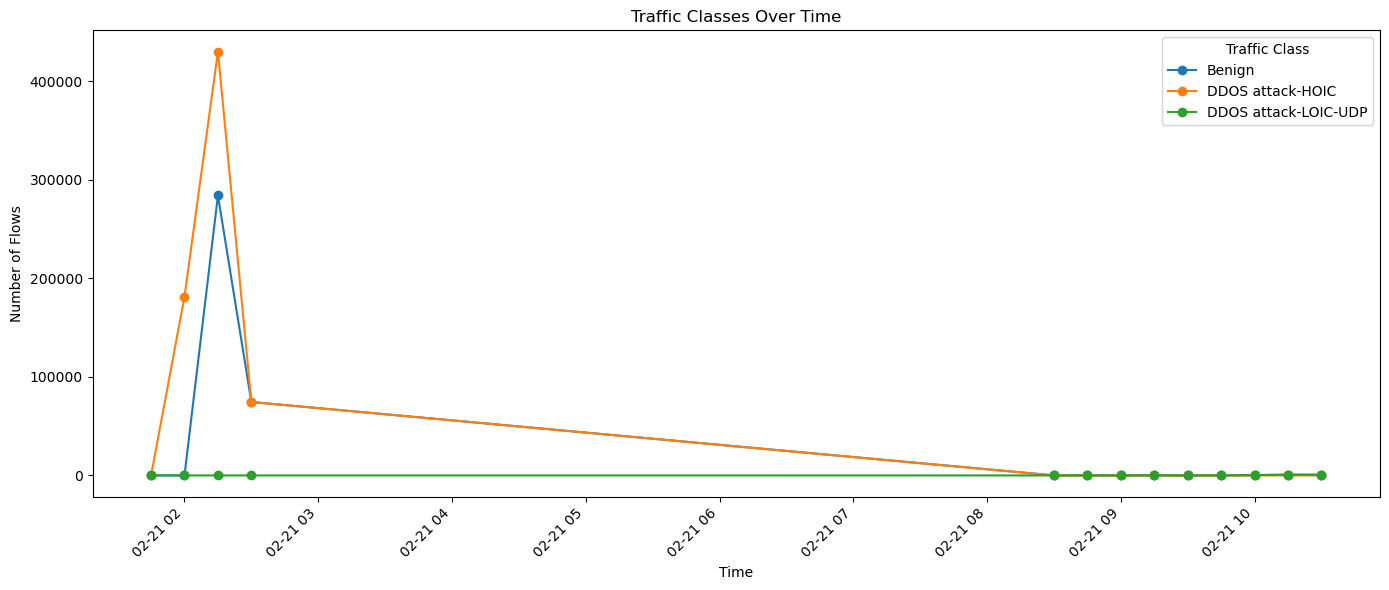

In [27]:
import matplotlib.pyplot as plt

time_profile.plot(
    figsize=(14, 6),
    marker="o"
)

plt.title("Traffic Classes Over Time")
plt.xlabel("Time")
plt.ylabel("Number of Flows")
plt.legend(title="Traffic Class")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
# Find the first and last timestamp for each traffic class

class_time_range = (
    time_df
    .groupby("Label")["Timestamp"]
    .agg(["min", "max", "count"])
    .sort_values("min")
)

display(class_time_range)

,min,max,count
Label,,,
Benign,2018-02-21 01:55:46,2018-02-21 10:43:21,360833
DDOS attack-HOIC,2018-02-21 02:11:08,2018-02-21 02:33:29,686012
DDOS attack-LOIC-UDP,2018-02-21 10:08:51,2018-02-21 10:43:16,1730


In [29]:
# Check constant features across the ENTIRE dataset

constant_features_full = None
first_chunk = True

for chunk in pd.read_csv(file_path, chunksize=50_000):

    # Count unique values in this chunk
    chunk_unique = chunk.nunique(dropna=False)

    if first_chunk:
        full_unique = chunk_unique.copy()
        first_chunk = False
    else:
        # We only need to know whether a column has
        # more than one value anywhere in the full file.
        full_unique = pd.concat(
            [full_unique, chunk_unique],
            axis=1
        ).max(axis=1)

constant_features_full = full_unique[full_unique <= 1].index.tolist()

print("Constant features in FULL dataset:")
for feature in constant_features_full:
    print("-", feature)

print("\nTotal constant features:", len(constant_features_full))

Constant features in FULL dataset:
- Bwd PSH Flags
- Fwd URG Flags
- Bwd URG Flags
- CWE Flag Count
- Fwd Byts/b Avg
- Fwd Pkts/b Avg
- Fwd Blk Rate Avg
- Bwd Byts/b Avg
- Bwd Pkts/b Avg
- Bwd Blk Rate Avg

Total constant features: 10


In [30]:
print("ALL DATASET COLUMNS\n")

for i, col in enumerate(df_sample.columns, start=1):
    print(f"{i:02d}. {col}")

ALL DATASET COLUMNS

01. Dst Port
02. Protocol
03. Timestamp
04. Flow Duration
05. Tot Fwd Pkts
06. Tot Bwd Pkts
07. TotLen Fwd Pkts
08. TotLen Bwd Pkts
09. Fwd Pkt Len Max
10. Fwd Pkt Len Min
11. Fwd Pkt Len Mean
12. Fwd Pkt Len Std
13. Bwd Pkt Len Max
14. Bwd Pkt Len Min
15. Bwd Pkt Len Mean
16. Bwd Pkt Len Std
17. Flow Byts/s
18. Flow Pkts/s
19. Flow IAT Mean
20. Flow IAT Std
21. Flow IAT Max
22. Flow IAT Min
23. Fwd IAT Tot
24. Fwd IAT Mean
25. Fwd IAT Std
26. Fwd IAT Max
27. Fwd IAT Min
28. Bwd IAT Tot
29. Bwd IAT Mean
30. Bwd IAT Std
31. Bwd IAT Max
32. Bwd IAT Min
33. Fwd PSH Flags
34. Bwd PSH Flags
35. Fwd URG Flags
36. Bwd URG Flags
37. Fwd Header Len
38. Bwd Header Len
39. Fwd Pkts/s
40. Bwd Pkts/s
41. Pkt Len Min
42. Pkt Len Max
43. Pkt Len Mean
44. Pkt Len Std
45. Pkt Len Var
46. FIN Flag Cnt
47. SYN Flag Cnt
48. RST Flag Cnt
49. PSH Flag Cnt
50. ACK Flag Cnt
51. URG Flag Cnt
52. CWE Flag Count
53. ECE Flag Cnt
54. Down/Up Ratio
55. Pkt Size Avg
56. Fwd Seg Size Avg
57. Bwd

In [31]:
# Look for columns that might behave like IDs or dataset-specific identifiers

print("Potential identifier-like columns:\n")

for col in df_sample.columns:
    unique_count = df_sample[col].nunique(dropna=False)
    unique_ratio = unique_count / len(df_sample)

    if unique_ratio > 0.95:
        print(
            f"{col:35} "
            f"unique={unique_count:6} "
            f"ratio={unique_ratio:.3f}"
        )

Potential identifier-like columns:

